# Figure S4

This notebook tests how the directed-evolution time horizon changes the NK strategy lookup. It compares optimal base chance and splitting for $M=25$, $50$, and $100$ generations using otherwise matched NK strategy sweeps.

## Setup

Load the Figure 5 strategy-grid products, serialisation utilities, and plotting functions. Define the three generation horizons, raw and processed paths, overwrite controls, and shared figure styling.

Cached raw and processed products can be installed from the repository root with `python slide/download_zenodo_data.py`. The notebook can generate missing products when its overwrite and plot-only settings permit it.

In [11]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import subprocess
import sys
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
REPO_ROOT = Path.cwd()
print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")
print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a figure in PDF, PNG, and EPS formats.

    Parameters:
    - fig: Figure
        Matplotlib figure to save.
    - stem: str
        Filename stem without an extension.
    - bbox_inches: str
        Bounding-box mode passed to Matplotlib.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a bold manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the annotation.
    - letter: str
        Panel letter.

    Returns:
    - None
        The annotation is added directly to ``ax``.
    """
    ax.text(-0.14, 1.10, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
            fontweight="bold", va="top", ha="left")

RAW_FILES = {
    25: RAW_DATA_DIR / "nk_strategy_grid_raw_data.pkl",
    50: RAW_DATA_DIR / "nk_strategy_grid_M50_raw_data.pkl",
    100: RAW_DATA_DIR / "nk_strategy_grid_M100_raw_data.pkl",
}
PROCESSED_PATH = PROCESSED_DATA_DIR / "figureS4_strategy_lookup_processed.pkl"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/lady5906/workspace_python/SLIDE/raw_data
processed_data: /home/lady5906/workspace_python/SLIDE/processed_data
figures: /home/lady5906/workspace_python/SLIDE/figures
PLOT_ONLY=True, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


## Raw Data — NK Strategy Grids at Three Time Horizons

Generate or load matched NK strategy sweeps for $M=25$, $50$, and $100$ directed-evolution generations. At each $(N,K)$ pair, every encoded base-chance and splitting combination is evaluated across the landscape and simulation replicates stored in the payload. Comparing horizons tests whether the strategy that maximises final performance changes when directed evolution is allowed to run longer.

In [12]:
if OVERWRITE_RAW_PKL and not PLOT_ONLY:
    targets = {25: "nk_strategy_grid", 50: "nk_strategy_grid_M50", 100: "nk_strategy_grid_M100"}
    for generations, target in targets.items():
        command = [sys.executable, "scripts/generate_figure5_raw_data.py", "--only", target]
        if RAW_FILES[generations].exists():
            command.append("--force")
        subprocess.run(command, cwd=REPO_ROOT, check=True)

missing_raw_paths = [path for path in RAW_FILES.values() if not path.exists()]
if missing_raw_paths:
    listing = "\n".join(f"  - {path}" for path in missing_raw_paths)
    raise FileNotFoundError(f"Figure S4 requires these raw grids:\n{listing}")
raw_payloads = {generations: load_pickle(path) for generations, path in RAW_FILES.items()}


## Processing — Horizon-Specific Strategy Lookups

For each generation horizon and $(N,K)$ pair, average strategy performance over the final replicate axis to obtain a base-chance-by-splitting surface and select its maximum. Convert each pair to $\rho_{NK}=(K+1)/N$, group values after rounding ruggedness to one decimal place, and calculate the mean and standard deviation of the optimal base chance and splitting in every group.

In [13]:
def process_figure_s4_payload(raw_payloads: dict[int, dict[str, object]]) -> dict[str, object]:
    """Reduce the M=25, 50, and 100 strategy grids to lookup summaries.

    Parameters:
    - raw_payloads: dict[int, dict[str, object]]
        Raw strategy grids keyed by generation count.

    Returns:
    - dict[str, object]
        Per-ruggedness-bin means and standard deviations for each horizon.
    """
    processed = {}
    for generations, payload in raw_payloads.items():
        data = np.asarray(payload["data"], dtype=float)
        params = payload["params"]
        base_chances = np.asarray(params["base_chances"], dtype=float)  # type: ignore[index]
        splits = np.asarray(params["splits"], dtype=int)  # type: ignore[index]
        pairs = np.asarray(params["nk_pairs"], dtype=int)  # type: ignore[index]
        rho = (pairs[:, 1] + 1) / pairs[:, 0]
        optimal_base, optimal_split = [], []
        for item in data:
            surface = item.mean(axis=-1)
            row, column = np.unravel_index(np.nanargmax(surface), surface.shape)
            optimal_base.append(base_chances[column])
            optimal_split.append(splits[row])
        rounded = np.round(rho, 1)
        grouped = np.unique(rounded)
        processed[generations] = {
            "rho": grouped,
            "base_mean": np.asarray([np.mean(np.asarray(optimal_base)[rounded == value]) for value in grouped]),
            "base_std": np.asarray([np.std(np.asarray(optimal_base)[rounded == value]) for value in grouped]),
            "split_mean": np.asarray([np.mean(np.asarray(optimal_split)[rounded == value]) for value in grouped]),
            "split_std": np.asarray([np.std(np.asarray(optimal_split)[rounded == value]) for value in grouped]),
        }
    return {
        "data": processed,
        "params": {"generation_counts": tuple(sorted(raw_payloads))},
        "metadata": {"paper_reference": "Figure S4"},
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure_s4_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {PROCESSED_PATH}")
else:
    figure_s4_payload = process_figure_s4_payload(raw_payloads)
    save_pickle(figure_s4_payload, PROCESSED_PATH)


## Individual Panels A–C

Plot the mean optimal base chance and splitting against $\rho_{NK}$ separately for the 25-, 50-, and 100-generation lookups, with shaded dispersion across NK settings in each ruggedness group.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


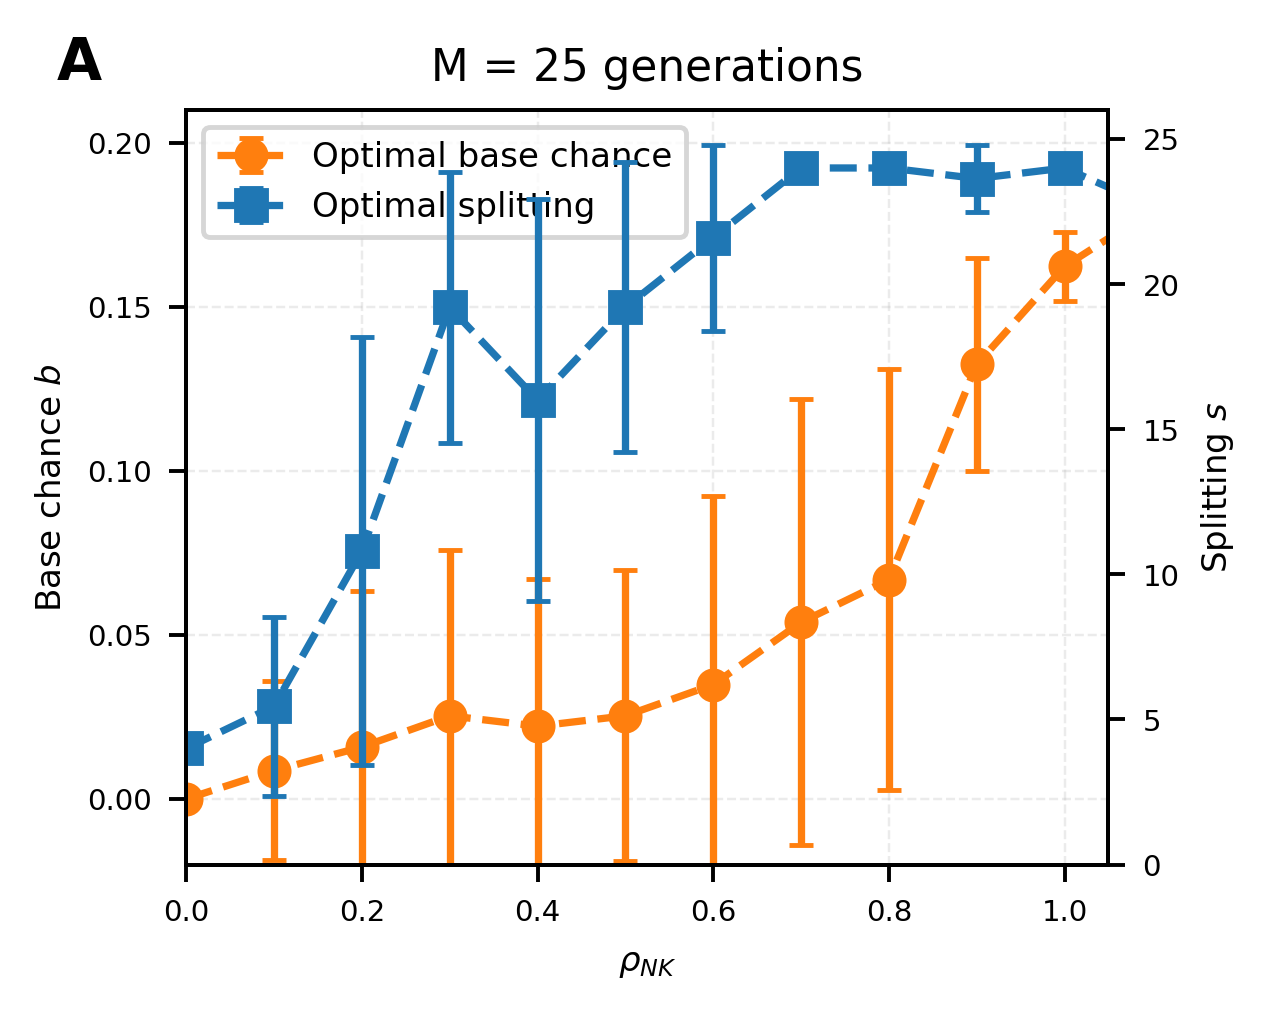

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


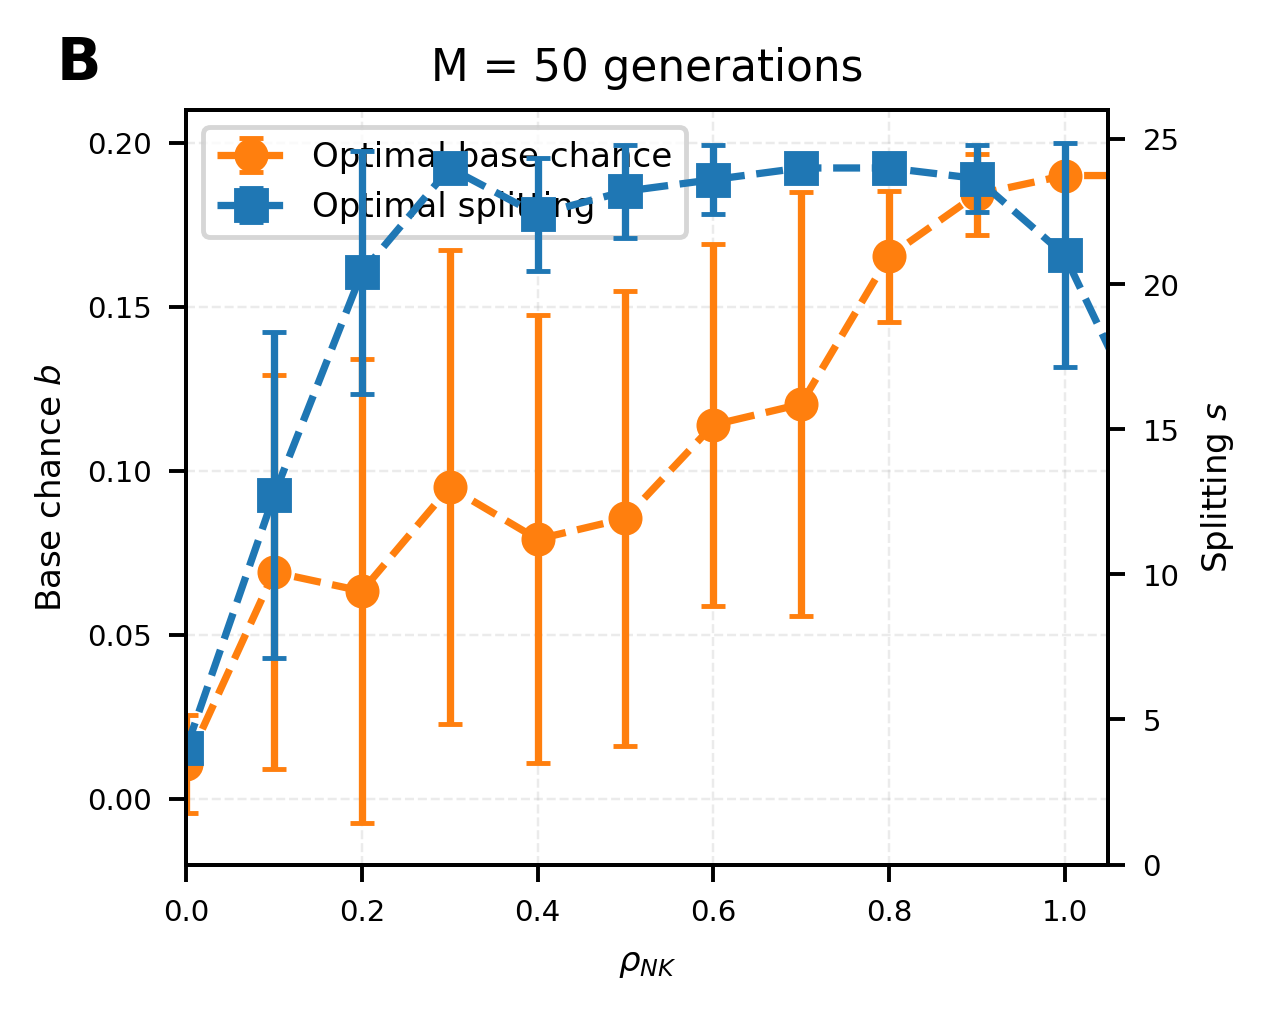

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


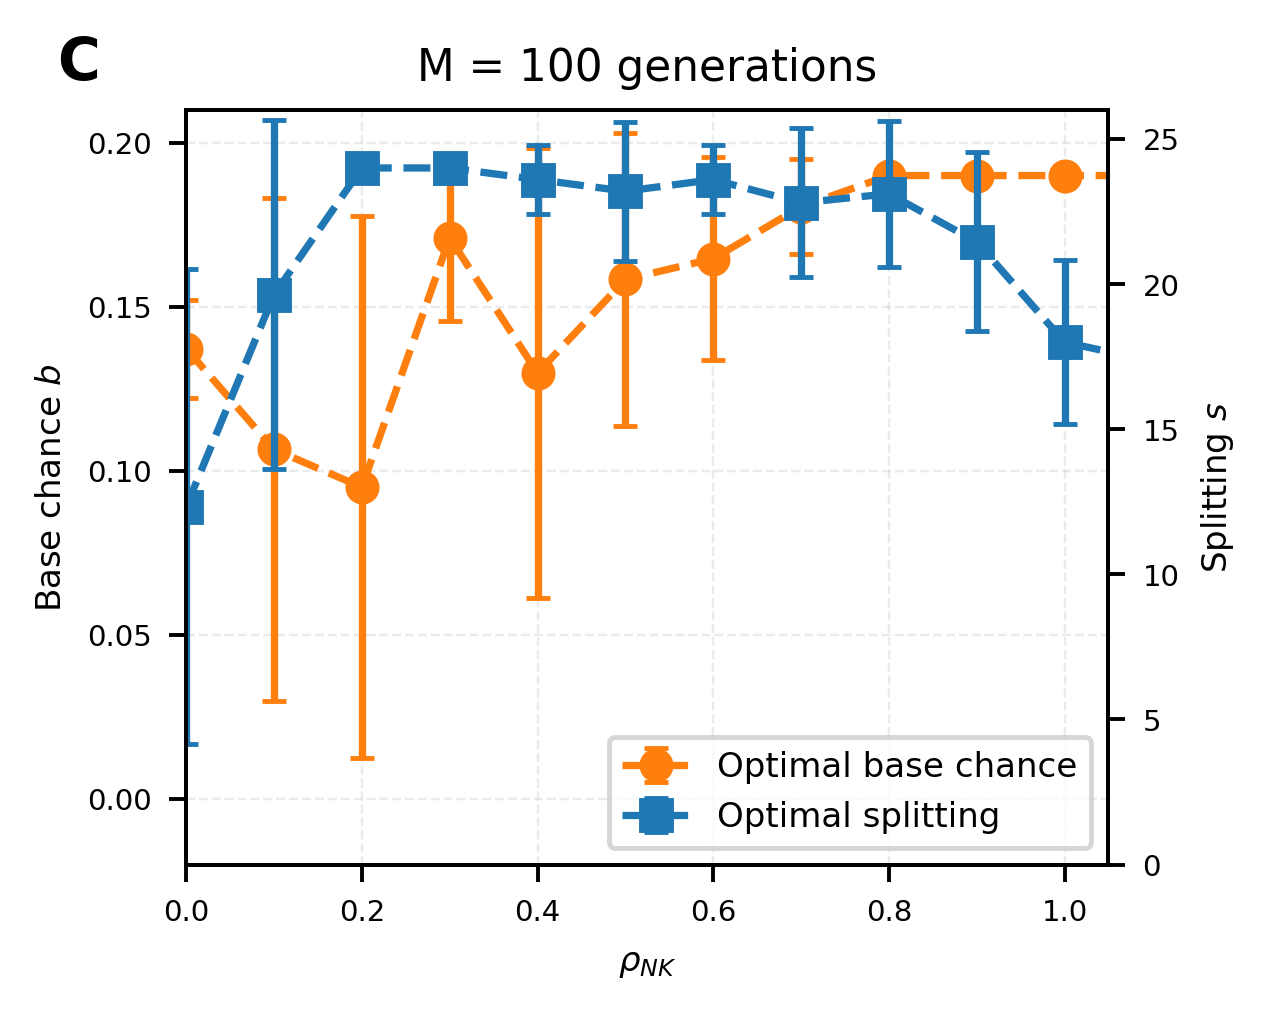

In [14]:
def plot_s4_panel(ax: Axes, payload: dict[str, object], generations: int) -> Axes:
    """Plot one strategy-lookup horizon with a twin splitting axis.

    Parameters:
    - ax: Axes
        Primary base-chance axis.
    - payload: dict[str, object]
        Processed Figure S4 payload.
    - generations: int
        Directed-evolution horizon.

    Returns:
    - Axes
        Twin axis used for splitting.
    """
    panel = payload["data"][generations]  # type: ignore[index]
    twin = ax.twinx()
    ax.errorbar(panel["rho"], panel["base_mean"], yerr=panel["base_std"], fmt="o--",
                capsize=2.5, color="tab:orange", label="Optimal base chance")
    twin.errorbar(panel["rho"], panel["split_mean"], yerr=panel["split_std"], fmt="s--",
                  capsize=2.5, color="tab:blue", label="Optimal splitting")
    ax.set_title(f"M = {generations} generations", fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel(r"$\rho_{NK}$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(r"Base chance $b$", fontsize=FIGURE_LABEL_SIZE)
    twin.set_ylabel(r"Splitting $s$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(-0.02, 0.21)
    twin.set_ylim(0, 26)
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    twin.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.5)
    return twin


for letter, generations in zip("ABC", (25, 50, 100), strict=True):
    fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
    twin = plot_s4_panel(ax, figure_s4_payload, generations)
    add_panel_letter(ax, letter)
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = twin.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, fontsize=7, frameon=True)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_S4{letter}")
    plt.show()


## Complete Figure

Arrange the three horizon-specific strategy lookups in the complete Figure S4 layout using shared axes and styling.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


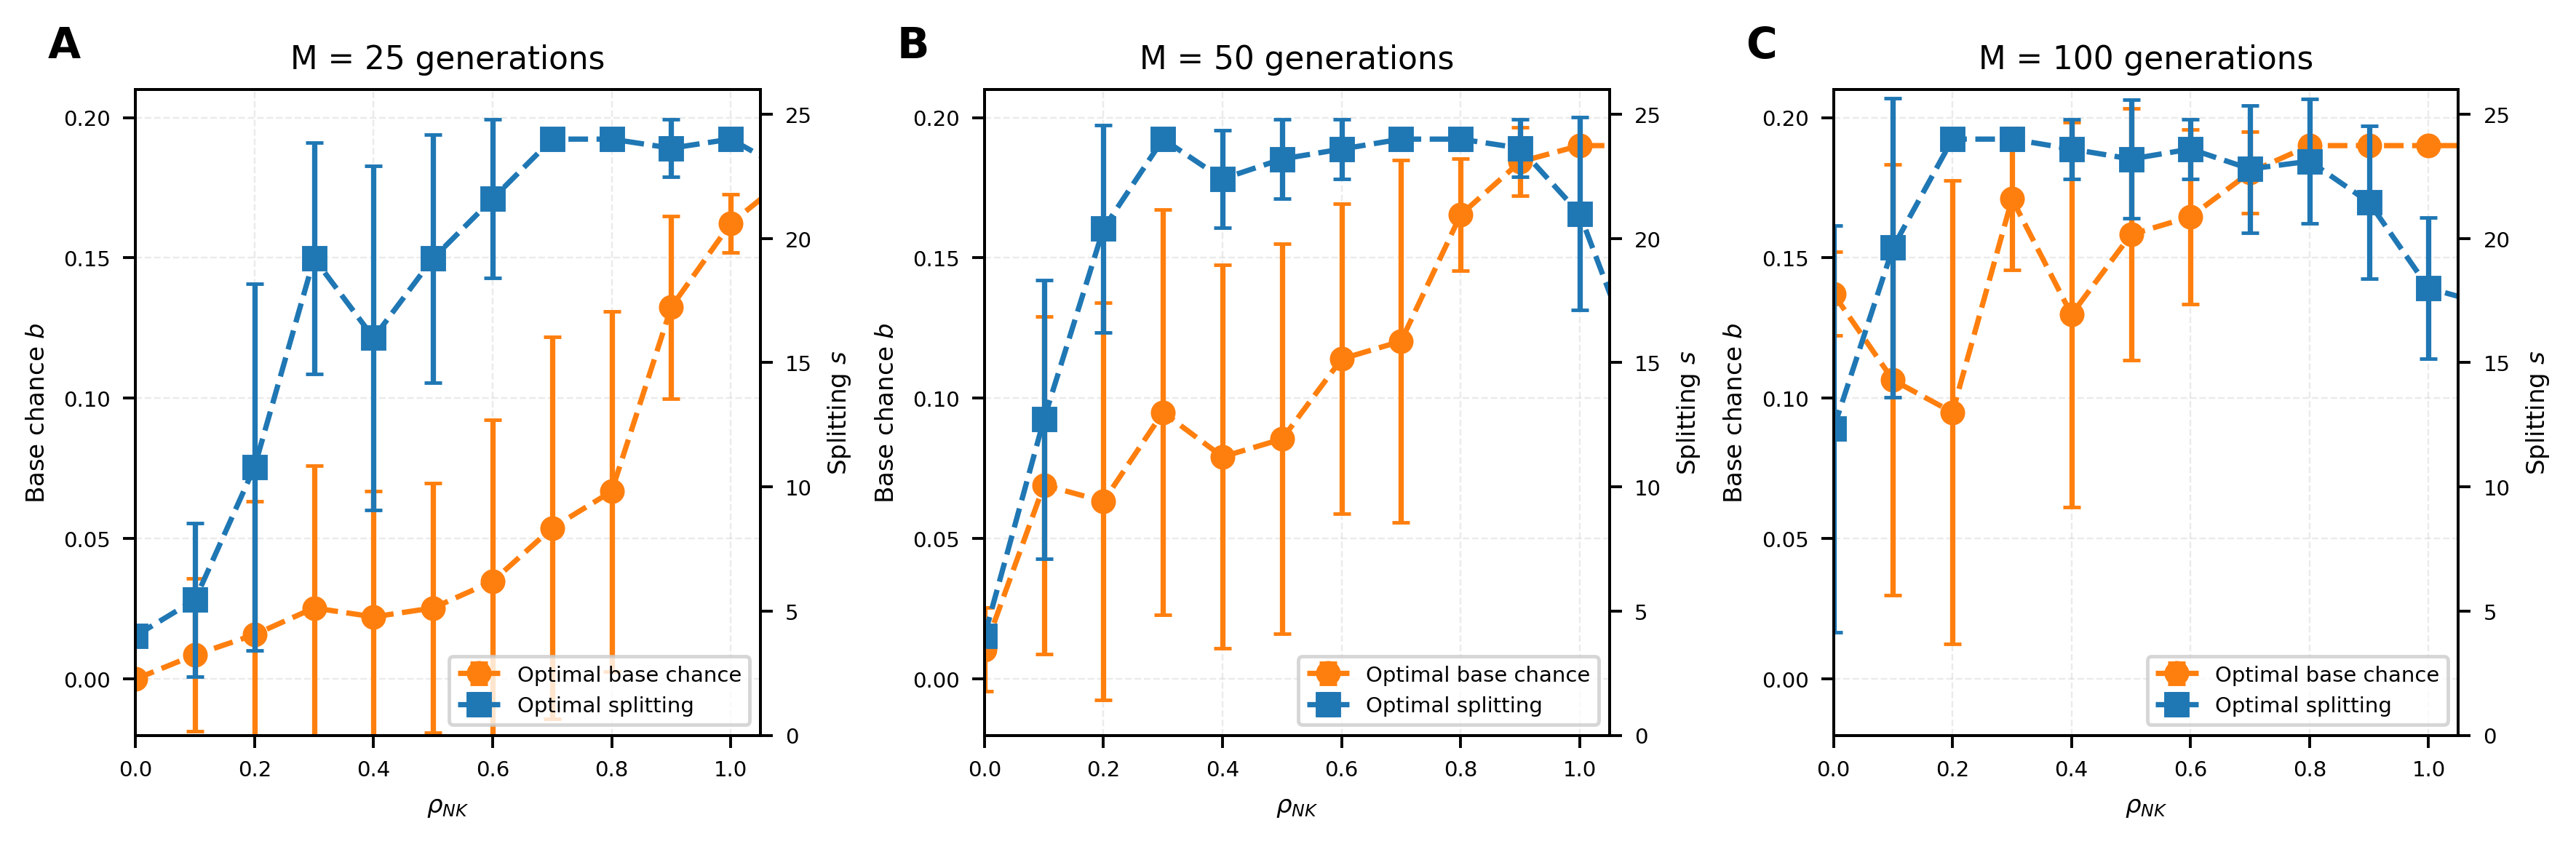

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), dpi=PANEL_DPI, constrained_layout=True)
twins = []
for ax, letter, generations in zip(axes, "ABC", (25, 50, 100), strict=True):
    twins.append(plot_s4_panel(ax, figure_s4_payload, generations))
    add_panel_letter(ax, letter)
handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = twins[0].get_legend_handles_labels()
for ax in axes:
    ax.legend(handles1 + handles2, labels1 + labels2, fontsize=FIGURE_LEGEND_SIZE, loc="lower right", ncol=1)
if SAVE_FIGURES:
    save_figure(fig, "figure_S4")
plt.show()
